# Goodreads Machine Learning - Group Project
------------
------------


## Decision/Actions Log : Executif Summary (updated sequentially)
1. clean raw data with 13 columns instead of 12 by concatenating authors column that spilled into average_rating column (fixed manually)
2. clean columns with leading/trailing spaces
3. clean publication_date column (2 errors found, fixed manually with isbn web search)
4. add a column fot publication_year
5. sanitize strings and add a column for clean_title, clean_authors, clean_publisher
6. add a column for the first author and the number of authors


## 0. Import libraries & Helper functions
----------

In [245]:
import re
import unicodedata
from typing import Any

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [246]:
def plot_distribution_with_mean(
    data,
    column,
    *,
    lower=0,
    upper=1500,
    title=None,
    xlabel=None,
    bins=40,
    color="#2a9d8f",
    mean_color="#e76f51",
    figsize=(9, 5),
    show_metrics=True,
):
    """Histogram + KDE with mean line, clipped to [lower, upper]."""
    series = data[column].dropna()
    series = series[(series >= lower) & (series <= upper)]

    col_mean = series.mean()
    col_std = series.std()

    plot_title = title or f"Distribution of {column} ({lower}–{upper})"
    plot_xlabel = xlabel or column

    fig, ax = plt.subplots(figsize=figsize)
    sns.histplot(series, bins=bins, kde=True, color=color, ax=ax)
    ax.axvline(
        col_mean,
        color=mean_color,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {col_mean:.3f}",
    )
    ax.set_xlim(lower, upper)
    ax.set_title(plot_title)
    ax.set_xlabel(plot_xlabel)
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    if show_metrics:
        display(pd.DataFrame({
            "metric": ["mean", "standard_deviation", "minimum", "maximum", "count"],
            "value": [col_mean, col_std, series.min(), series.max(), len(series)],
        }))

    return fig, ax

In [247]:
def normalize_string(
    value: Any,
    *,
    lowercase: bool = True,
    strip_accents: bool = True,
    collapse_whitespace: bool = True,
    remove_suffixes: bool = False,
    remove_punctuation: bool = False,
) -> str | None:
    """
    Normalize a single string for fuzzy matching / grouping keys.
    Returns None for None/NaN. Non-strings are cast to str first.
    """
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    s = str(value).strip()
    if not s:
        return ""
    if lowercase:
        s = s.lower()
    if strip_accents:
        s = unicodedata.normalize("NFKD", s)
        s = "".join(c for c in s if not unicodedata.combining(c))
    if collapse_whitespace:
        s = re.sub(r"\s+", " ", s)
    if remove_suffixes:
        s = re.sub(
            r"\s+(jr\.?|sr\.?|iii|ii|iv)$",
            "",
            s,
            flags=re.IGNORECASE,
        ).strip()
    if remove_punctuation:
        s = re.sub(r"[^\w\s]", "", s)
        s = re.sub(r"\s+", " ", s).strip()
    return s

--------------------------------------
--------------------------------------
## 1. Loading Data
--------------------------------------
--------------------------------------

In [248]:
CSV_RAW_PATH = "../data/raw/books.csv"

In [249]:
df = pd.read_csv(CSV_RAW_PATH, index_col="bookID", on_bad_lines='warn')


C:\Users\Hugo\AppData\Local\Temp\ipykernel_6908\1247233899.py:1: ParserWarning: Skipping line 3350: expected 12 fields, saw 13
Skipping line 4704: expected 12 fields, saw 13
Skipping line 5879: expected 12 fields, saw 13
Skipping line 8981: expected 12 fields, saw 13

  df = pd.read_csv(CSV_RAW_PATH, index_col="bookID", on_bad_lines='warn')


Upon inspection, the 4 errors came from the fact that the author string contained a comma "," which was interpreted as a new column and spilled the author name into the nex column when creating the .csv, thus resulting in 13 columns instead of 12

In [250]:
# the 4 errors were manualy fixed (joining the 2 columns with "," for these 4 error rows)
CSV_CLEANED_PATH = "../data/processed/books-hugo.csv" 
df = pd.read_csv(CSV_CLEANED_PATH, on_bad_lines='warn')

------------------------------------------
------------------------------------------
## 2. EDA & Cleaning Data
------------------------------------------
------------------------------------------

In [251]:
df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [252]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11127 entries, 0 to 11126
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11127 non-null  int64  
 1   title               11127 non-null  str    
 2   authors             11127 non-null  str    
 3   average_rating      11127 non-null  float64
 4   isbn                11127 non-null  str    
 5   isbn13              11127 non-null  int64  
 6   language_code       11127 non-null  str    
 7     num_pages         11127 non-null  int64  
 8   ratings_count       11127 non-null  int64  
 9   text_reviews_count  11127 non-null  int64  
 10  publication_date    11127 non-null  str    
 11  publisher           11127 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


### **observations :**
- It looks like there is a leading space for the " num_pages" column name
- isbn13 as int64 seems like the wrong type for and identifier, but not a big deal because we will probably drop these columns
- publication_date as string is not ideal, should be parsed to date

In [253]:
# check if bookID, ISBN, ISBN13 are all uniques
cols = ["bookID", "isbn", "isbn13"]
{col: df[col].is_unique for col in cols}

{'bookID': True, 'isbn': True, 'isbn13': True}

**Set index**

In [254]:
# since all are unique, we can select any for indexing, lets select bookID
df.set_index("bookID", inplace=True)

**Fix trailing/leading spaces**

In [255]:
# fix column names
df.columns = df.columns.str.strip()

In [256]:
# test if any of the values contains leading/trailing spaces
for col in df.columns:
    if df[col].dtype == "str":
        has_spaces = df[col].dropna().ne(df[col].dropna().str.strip()).any()
        if has_spaces:
            print(f"!! Leading/trailing spaces detected in column: {col}")
        else:
            print(f"no spaces detected on column : {col}")



!! Leading/trailing spaces detected in column: title
no spaces detected on column : authors
no spaces detected on column : isbn
no spaces detected on column : language_code
no spaces detected on column : publication_date
no spaces detected on column : publisher


In [257]:
# fix spaces in titles
df["title"] = df["title"].str.strip()


**Convert publication date to datetime**

In [258]:
# fix publication_date, passing format to parse
pub_raw = df["publication_date"].copy()
df["publication_date"] = pd.to_datetime(
    df["publication_date"],
    format="%m/%d/%Y",
    errors="coerce", # if the format is not correct, set to NaT
)
# check original values where the conversion failed
pub_raw.loc[df["publication_date"].isna()]

bookID
31373    11/31/2000
45531     6/31/1982
Name: publication_date, dtype: str

2 dates did not convert properly : these dates are impossible, lets check ISBN code and look for the information on the internet since there is only 2 books with invalid dates

In [259]:
# check ISBN13 code
df.loc[df.publication_date.isna(), ["isbn","isbn13","title"]]

,isbn,isbn13,title
bookID,,,
31373,0553575104,9780553575101,In Pursuit of the Proper Sinner (Inspector Lyn...
45531,2070323285,9782070323289,Montaillou village occitan de 1294 à 1324


According to current goodreads.com: 
- *In Pursuit of the Proper Sinner* was puplished in October 31st, 2000
- *Montaillou  village occitan de 1294 à 1324* was published in June 30, 1982

One date is wrong by 1 day, the other by 1 month. 

These errors could be isolated, or might be a symptom of a larger issue with dates. Some of the parsable date might still be wrong. Goodreads.com does not provide a public API to check the data programmatically (an unofficial one exist on Apify), but there are other options to check the publishing date with Open Library or Google Books API.  

Lets apply a target fix:

In [260]:
# fix the dates by index
df.loc[31373, "publication_date"] = pd.to_datetime("2000-10-31")
df.loc[45531, "publication_date"] = pd.to_datetime("1982-06-30")

Lets take the opportunity to add a new column for year of publication as it will be more usefull that the exact date

In [261]:
df["publication_year"] = df["publication_date"].dt.year

**String Sanitization : apply normalization function**

In [262]:
df["clean_title"] = df["title"].apply(normalize_string)
df["clean_authors"] = df["authors"].apply(normalize_string)
df["clean_publisher"] = df["publisher"].apply(normalize_string)

**Creating new colums for *Authors* : inspection of the data show that authors are separated by "/"**

In [263]:
# check what is the maximum number of authors for one book
n_authors = df["clean_authors"].str.split("/").str.len()
n_authors.max()

np.int64(51)

51 authors for one book !

In [264]:
cols = ["title", "clean_authors"]
df.loc[n_authors == n_authors.max(), cols]

,title,clean_authors
bookID,,
39690,Good Poems for Hard Times,garrison keillor/charles bukowski/robert burns...


To avoid empty data, and because usually the first author is usually the main one (confirmed below), lets add a column for the first author only, and one column with the number of authors

In [ ]:
# creating new columns
df["first_author"] = df["clean_authors"].str.split("/").str[0].str.strip()
df["n_authors"] = n_authors

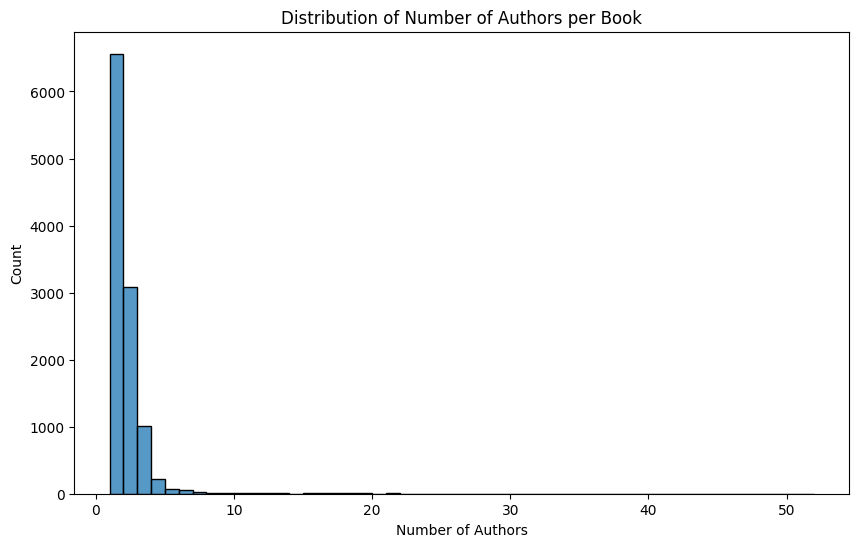

In [266]:
# plot showing the number of authors per book
plt.figure(figsize=(10, 6))
sns.histplot(df["n_authors"], bins=range(1, n_authors.max() + 2))
plt.title("Distribution of Number of Authors per Book")
plt.xlabel("Number of Authors")
plt.ylabel("Count")
plt.show()

It looks like books with more than 10 authors are rare, we might want to remove them from the dataset or use a logaritmic scale later on.

## Looking for blank/empty/null/bad data


In [267]:
df.describe()

,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,publication_date,publication_year,n_authors
count,11127.000000,1.112700e+04,11127.000000,1.112700e+04,11127.000000,11127,11127.000000,11127.000000
mean,3.933631,9.759888e+12,336.376921,1.793641e+04,541.854498,2000-08-27 22:58:00.614721,2000.167520,1.729487
min,0.000000,8.987060e+09,0.000000,0.000000e+00,0.000000,1900-01-01 00:00:00,1900.000000,1.000000
25%,3.770000,9.780345e+12,192.000000,1.040000e+02,9.000000,1998-07-16 12:00:00,1998.000000,1.000000
50%,3.960000,9.780586e+12,299.000000,7.450000e+02,46.000000,2003-03-01 00:00:00,2003.000000,1.000000
75%,4.135000,9.780873e+12,416.000000,4.993500e+03,237.500000,2005-09-30 00:00:00,2005.000000,2.000000
max,5.000000,9.790008e+12,6576.000000,4.597666e+06,94265.000000,2020-03-31 00:00:00,2020.000000,51.000000
std,0.352445,4.428964e+11,241.127305,1.124794e+05,2576.176608,NaN,8.248836,1.819852


At first glance, we can see that there are rows with num_pages, ratings_count and text_reviews_count equal to 0  
➜ should be investigated and cleaned

In [268]:
df.isna().sum()

title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
num_pages             0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
publication_year      0
clean_title           0
clean_authors         0
clean_publisher       0
first_author          0
n_authors             0
dtype: int64

Check for other bad/empty data :

In [269]:
# check for bad data
bad_inputs = ["", "nan", "None", "N/A", "null", "-"]
bad_results = {}
for col in df.columns:
    mask = df[col].astype(str).str.strip().str.lower().isin(bad_inputs)
    bad_results[col] = int(mask.sum())
bad_results


{'title': 0,
 'authors': 0,
 'average_rating': 0,
 'isbn': 0,
 'isbn13': 0,
 'language_code': 0,
 'num_pages': 0,
 'ratings_count': 0,
 'text_reviews_count': 0,
 'publication_date': 0,
 'publisher': 0,
 'publication_year': 0,
 'clean_title': 0,
 'clean_authors': 0,
 'clean_publisher': 0,
 'first_author': 0,
 'n_authors': 0}

➜ no strictly missing values

In [270]:
print("num_pages zero count :",(df["num_pages"] == 0).sum())
print("ratings_count zero count :",(df["ratings_count"] == 0).sum())
print("text_reviews_count zero count :",(df["text_reviews_count"] == 0).sum())

num_pages zero count : 76
ratings_count zero count : 81
text_reviews_count zero count : 625


**What to do with these : further analysis needed**

num_pages = 0 ➜ encode average/median?  
ratings_count = 0 ➜ drop ?
text_reviews_count = 0 ➜ could be an actual signal, keep ?

## Looking for silent duplicates
------------------------

We already established that there are no strict duplicates, since bookID, isbn and isbn13 are all uniques

**Title duplicates**

In [271]:
# number of duplicated titles
(df["title"].value_counts()>1).sum()

np.int64(487)

In [272]:
# number of duplicated titles
(df["clean_title"].value_counts() > 1).sum()

np.int64(534)

The "clean_title" is a sanitized version of the title, it is more reliable to use it for duplicate detection but we need to check if there are some cases where the clean_title is the same but the title is actually different on purpose.



There are a few duplicated titles, but they might have different authors

In [273]:
#  duplicated titles & authors
dup_counts = df[["title", "authors"]].value_counts()
(dup_counts > 1).sum()
# (df[["title","authors"]].value_counts()>1).sum()

np.int64(263)

487 duplicated titles, 263 duplicates by title & authors

In [274]:
# check if there exist books with same title and authors, but different ratings
(df.groupby(["title","authors"])["average_rating"].nunique() > 1).any()

np.False_

In [275]:
# check if there exist books with same clean_title and authors, but different ratings
(df.groupby(["clean_title", "authors"])["average_rating"].nunique() > 1).any()

np.False_

Good news, duplicated books (by title & authors) all have the same ratings

In [276]:
# number of book with same title but different authors
df_same_title_not_authors = df.groupby(["title"])["authors"].nunique() > 1
df_same_title_not_authors.sum()

np.int64(282)

In [277]:
df["title"].value_counts()

title
The Iliad                                           9
The Brothers Karamazov                              9
Anna Karenina                                       8
The Odyssey                                         8
'Salem's Lot                                        8
                                                   ..
Expelled from Eden: A William T. Vollmann Reader    1
You Bright and Risen Angels                         1
The Ice-Shirt (Seven Dreams #1)                     1
Poor People                                         1
Las aventuras de Tom Sawyer                         1
Name: count, Length: 10352, dtype: int64

In [278]:
df[df["title"] == "The Iliad"][:]

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,publication_year,clean_title,clean_authors,clean_publisher,first_author,n_authors
bookID,,,,,,,,,,,,,,,,,
1371,The Iliad,Homer/Robert Fagles/Bernard Knox,3.86,0140275363,9780140275360,eng,683,288792,3423,1999-04-29,Penguin Classics,1999,the iliad,homer/robert fagles/bernard knox,penguin classics,homer,3
1374,The Iliad,Homer/Robert Fitzgerald/Andrew Ford,3.86,0374529051,9780374529055,en-US,588,692,81,2004-04-03,Farrar Straus and Giroux,2004,the iliad,homer/robert fitzgerald/andrew ford,farrar straus and giroux,homer,3
1376,The Iliad,Homer/E.V. Rieu/Peter Jones/D.C.H. Rieu,3.86,0140447946,9780140447941,eng,462,1919,118,2003-01-30,Penguin Classics,2003,the iliad,homer/e.v. rieu/peter jones/d.c.h. rieu,penguin classics,homer,4
1377,The Iliad,Homer/W.H.D. Rouse,3.86,0451527372,9780451527370,en-US,312,158,15,1999-08-01,Signet Classics,1999,the iliad,homer/w.h.d. rouse,signet classics,homer,2
1796,The Iliad,Homer/Robert Fitzgerald,3.86,1857150600,9781857150605,eng,594,30,2,1992-03-19,Everyman,1992,the iliad,homer/robert fitzgerald,everyman,homer,2
12254,The Iliad,Homer/Robert Fagles/Derek Jacobi,3.86,0143059289,9780143059288,eng,8,42,7,2006-06-15,Penguin-HighBridge,2006,the iliad,homer/robert fagles/derek jacobi,penguin-highbridge,homer,3
22221,The Iliad,Homer,3.86,0471377589,9780471377580,eng,150,3834,134,1999-10-28,John Wiley & Sons,1999,the iliad,homer,john wiley & sons,homer,1
32780,The Iliad,Homer/Andrew Lang,3.86,1904633382,9781904633389,eng,542,64,8,2011-09-01,Collector's Library,2011,the iliad,homer/andrew lang,collector's library,homer,2
32782,The Iliad,Homer/Victor G. Ambrus/Nick McCarty,3.86,0753453215,9780753453216,eng,95,8,3,2000-09-15,Kingfisher,2000,the iliad,homer/victor g. ambrus/nick mccarty,kingfisher,homer,3


From this example, we can infer that even though the authors are differents, the first author is the same.
We might use this information to merge the books with the same title but different authors.

In [279]:
# number for books with same title but different first author
df_same_title_not_1st_author = df.groupby(
    ["title"])["first_author"].nunique() > 1
df_same_title_not_1st_author.sum()

np.int64(61)

It went down from 282 to 61

In [280]:
# with title sanitized, there are 47 additional duplicates, lets look at them
# raw where sanitize title is duplicated, but not title
title_counts = df["title"].value_counts()
clean_counts = df["clean_title"].value_counts()

dup_clean_keys = clean_counts[clean_counts > 1].index
unique_raw_titles = title_counts[title_counts == 1].index

# rows: clean title is in a duplicate group, but this row's raw title is unique
mask = (
    df["clean_title"].isin(dup_clean_keys)
    & df["title"].isin(unique_raw_titles)
)

cols = ["title", "clean_title", "authors","clean_authors","language_code", "average_rating"]

title_compare_table = df.loc[mask, cols].sort_values(["clean_title", "title"])
title_compare_table

,title,clean_title,authors,clean_authors,language_code,average_rating
bookID,,,,,,
32830,20 000 Leagues Under The Sea,20 000 leagues under the sea,Pauline Francis/Jules Verne,pauline francis/jules verne,eng,3.76
29603,20 000 Leagues Under the Sea,20 000 leagues under the sea,Ron Miller/Jules Verne/Paul Wright,ron miller/jules verne/paul wright,eng,3.76
13136,2nd Chance (Women's Murder Club #2),2nd chance (women's murder club #2),James Patterson/Andrew Gross,james patterson/andrew gross,eng,4.04
21426,2nd Chance (Women's Murder Club #2),2nd chance (women's murder club #2),James Patterson/Melissa Leo/Jeremy Piven/Andre...,james patterson/melissa leo/jeremy piven/andre...,eng,4.04
10572,A Clash of Kings (A Song of Ice and Fire #2),a clash of kings (a song of ice and fire #2),George R.R. Martin,george r.r. martin,eng,4.41
...,...,...,...,...,...,...
24945,The Wonderful Story Of Henry Sugar and Six More,the wonderful story of henry sugar and six more,Roald Dahl,roald dahl,eng,4.14
10203,View With a Grain of Sand: Selected Poems,view with a grain of sand: selected poems,Wisława Szymborska/Stanisław Barańczak/Clare C...,wisława szymborska/stanisław baranczak/clare c...,eng,4.33
10204,View with a Grain of Sand: Selected Poems,view with a grain of sand: selected poems,Wisława Szymborska,wisława szymborska,eng,4.33


In [281]:
print("comparison on title :",df.loc[32830, "title"] == df.loc[29603, "title"])
print("comparison on clean_title :",df.loc[32830, "clean_title"] == df.loc[29603, "clean_title"])

comparison on title : False
comparison on clean_title : True


In the case of *20 000 Leagues Under The Sea*, the title is different, but the clean_title is the same. A lower case "t" on "the" vs "The" is the culprit. We could assume that in most of the cases, if clean_title is the same, the title should be the same as well. However, there might be some case where clean_title is the same but the title should be different (removing an accent for example can mean a different title). unlikely but possible. only complete visualisation and manual inspection can confirm.

In the case of *Xenocide (Ender's Saga  #3)*, the title is different, because one of the version is the french version (with "é"), but the clean_title is the same.

This is hard to solve because in some cases, the translation might be completely different, and clean_title won't be the same. We might need to find a way to enrich the data with the *original title*, if we can find it, to be able to detect cases of translated books.  

One thing to point out is that the average rating is the same for the french version and the original english version. This could be a pattern.


One way to almost confirm if there are cases where the cleaned title gets matched with a different book if to check if there are different average ratings for the same clean_title

In [282]:
(df.groupby(["clean_title", "first_author"])
 ["average_rating"].nunique() > 1).any()

np.True_

In [283]:
# number of books with same clean_title but different average rating
(df.groupby(["clean_title", "first_author"])["average_rating"].nunique() > 1).any()

np.True_

In [284]:
# visualise the table by chunk of 10, and verify if the title should be the same or not
iteration = 10
title_compare_table[10*iteration:10*(iteration+1)]

,title,clean_title,authors,clean_authors,language_code,average_rating
bookID,,,,,,
9816,The View From Castle Rock,the view from castle rock,Alice Munro,alice munro,eng,3.68
9815,The View from Castle Rock,the view from castle rock,Alice Munro,alice munro,eng,3.68
18072,The Waste Lands (The Dark Tower #3),the waste lands (the dark tower #3),Stephen King/Ned Dameron,stephen king/ned dameron,eng,4.24
45213,The Woman In White,the woman in white,Wilkie Collins,wilkie collins,en-GB,4.00
24945,The Wonderful Story Of Henry Sugar and Six More,the wonderful story of henry sugar and six more,Roald Dahl,roald dahl,eng,4.14
10203,View With a Grain of Sand: Selected Poems,view with a grain of sand: selected poems,Wisława Szymborska/Stanisław Barańczak/Clare C...,wisława szymborska/stanisław baranczak/clare c...,eng,4.33
10204,View with a Grain of Sand: Selected Poems,view with a grain of sand: selected poems,Wisława Szymborska,wisława szymborska,eng,4.33
8648,Xenocide (Ender's Saga #3),xenocide (ender's saga #3),Orson Scott Card/Piotr W. Cholewa,orson scott card/piotr w. cholewa,eng,3.79
30026,Xénocide (Ender's Saga #3),xenocide (ender's saga #3),Orson Scott Card,orson scott card,fre,3.79


In [285]:
#cols = ["language_code", "publisher","publication_year", "num_pages", "average_rating", "ratings_count", "text_reviews_count"]

(
    df.groupby(["title", "authors"], as_index=False)
    .agg(
        n_copies=("title", "size"),
        language_code=("language_code", list),
        num_pages=("num_pages", list),
        publisher=("publisher", list),
        publication_year=("publication_year", list),
        average_rating=("average_rating", "first"), # we confirmed they are all the same
        ratings_count=("ratings_count", list),
        text_reviews_count=("text_reviews_count", list),
    )
    .query("n_copies > 1")
    .nlargest(10, "n_copies")
)

,title,authors,n_copies,language_code,num_pages,publisher,publication_year,average_rating,ratings_count,text_reviews_count
4,'Salem's Lot,Stephen King,5,"[eng, en-US, eng, eng, eng]","[405, 427, 586, 817, 427]","[Doubleday, Signet, Hodder & Stoughton Ltd, Si...","[1975, 1979, 2010, 1976, 1976]",4.02,"[1039, 178, 25, 18, 186]","[130, 35, 6, 3, 22]"
4687,Memoirs of a Geisha,Arthur Golden,5,"[eng, eng, en-US, eng, eng]","[503, 434, 497, 497, 452]","[Vintage Books USA, Random House Large Print P...","[2005, 2005, 2005, 1998, 2000]",4.11,"[280309, 1301083, 2122, 4189, 57]","[3703, 19296, 256, 462, 8]"
5333,One Hundred Years of Solitude,Gabriel García Márquez/Gregory Rabassa,5,"[eng, eng, eng, eng, eng]","[458, 417, 448, 560, 422]","[Harper Perennial, Turtleback Books, Harper Pe...","[2004, 2006, 2006, 2004, 1972]",4.07,"[3437, 90, 1608, 130, 640]","[316, 5, 212, 5, 65]"
6677,Sula,Toni Morrison,4,"[eng, eng, eng, eng]","[174, 174, 174, 189]","[Plume Books, Vintage International, Plume, Vi...","[2002, 2004, 1987, 2005]",3.93,"[47998, 3552, 457, 709]","[2479, 361, 49, 94]"
7799,The Enemy (Jack Reacher #8),Lee Child/Dick Hill,4,"[eng, eng, eng, eng]","[14, 14, 14, 14]","[Brilliance Audio, Brilliance Audio, Brillianc...","[2004, 2004, 2004, 2004]",4.16,"[178, 4, 3, 1]","[35, 0, 2, 0]"
9169,The Scarlet Letter,Nathaniel Hawthorne,4,"[eng, eng, eng, eng]","[400, 224, 538, 553]","[Simon & Schuster, Ann Arbor Media, Kaplan, Ka...","[2004, 2006, 2005, 2006]",3.40,"[1373, 109, 534, 23]","[68, 8, 11, 4]"
10040,Tripwire (Jack Reacher #3),Lee Child/Dick Hill,4,"[eng, en-US, eng, eng]","[3, 14, 14, 14]","[Nova Audio Books, Brilliance Audio, Brillianc...","[1999, 2004, 2004, 2004]",4.09,"[16, 3, 11, 18]","[3, 1, 1, 4]"
10476,White Teeth,Zadie Smith,4,"[eng, eng, eng, en-GB]","[448, 542, 448, 542]","[Vintage, Penguin Books, Turtleback Books, Pen...","[2001, 2001, 2001, 2000]",3.77,"[102370, 4202, 81, 1265]","[5677, 406, 11, 142]"
341,A Tale of Two Cities,Charles Dickens/Gillen D'Arcy Wood,3,"[eng, en-US, en-GB]","[409, 429, 409]","[Barnes & Noble Classics, Barnes Noble Classi...","[2004, 2003, 2004]",3.84,"[1343, 730, 301]","[183, 88, 44]"
369,A Walk in the Woods: Rediscovering America on ...,Bill Bryson,3,"[eng, eng, eng]","[284, 397, 276]","[Broadway Books, Anchor Books, Bantam Doubleda...","[1999, 2006, 1998]",4.06,"[4315, 308840, 1405]","[532, 14993, 266]"


As seen earlier, there are no truly duplicated rows, but some of the rows only differ by publisher or language code : average_rating is the same when title & authors are the same.  
We need to define a way to merge 

## Analysis : Average Rating (Target)
-----------

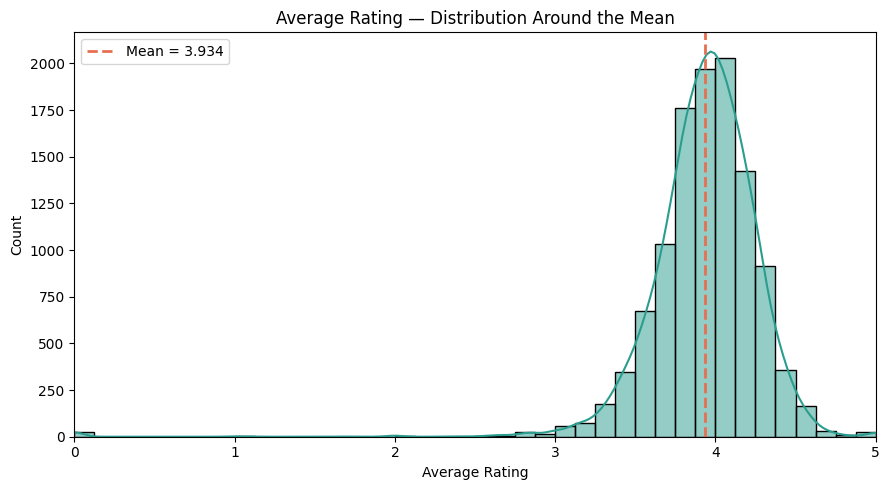

,metric,value
0,mean,3.933631
1,standard_deviation,0.352445
2,minimum,0.000000
3,maximum,5.000000
4,count,11127.000000


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Average Rating — Distribution Around the Mean'}, xlabel='Average Rating', ylabel='Count'>)

In [286]:
plot_distribution_with_mean(
    df,
    column="average_rating",
    lower=0,
    upper=df["average_rating"].max(),
    title="Average Rating — Distribution Around the Mean",
    xlabel="Average Rating",
)

**Interpretation**  
- distribution is heavily centered around the average : 3.93  
- a few books appear with average rating being zero

In [287]:
print("average_rating negative count :",(df["average_rating"] < 0).sum())

average_rating negative count : 0


## Analysis : Ratings Count
-----------

In [288]:
print("ratings_count zero with average_rating not zero:",((df["ratings_count"] == 0) & (df["average_rating"] != 0)).sum())

ratings_count zero with average_rating not zero: 55


This is an issue, a book shouldn't have a positive rating if the ratings count is zero

In [289]:
df[(df["ratings_count"] == 0) & (df["average_rating"] != 0)].head()

,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher,publication_year,clean_title,clean_authors,clean_publisher,first_author,n_authors
bookID,,,,,,,,,,,,,,,,,
797,Lonely Planet Londres,Lonely Planet/Sarah Johnstone/Tom Masters,4.03,8408064762,9788408064763,spa,480,0,0,2006-05-01,Geoplaneta,2006,lonely planet londres,lonely planet/sarah johnstone/tom masters,geoplaneta,lonely planet,3
1658,American Government: Continuity and Change Al...,Karen O'Connor/Larry J. Sabato,2.83,0321317106,9780321317100,eng,664,0,0,2005-03-11,Longman Publishing Group,2005,american government: continuity and change alt...,karen o'connor/larry j. sabato,longman publishing group,karen o'connor,2
1664,Essentials of American and Texas Government: C...,Karen O'Connor/Larry J. Sabato,3.50,0321365208,9780321365200,eng,854,0,0,2005-07-29,Longman Publishing Group,2005,essentials of american and texas government: c...,karen o'connor/larry j. sabato,longman publishing group,karen o'connor,2
2034,Comoediae 1: Acharenses/Equites/Nubes/Vespae/P...,Aristophanes/F.W. Hall/W.M. Geldart,5.00,0198145047,9780198145042,grc,364,0,0,1922-02-22,Oxford University Press USA,1922,comoediae 1: acharenses/equites/nubes/vespae/p...,aristophanes/f.w. hall/w.m. geldart,oxford university press usa,aristophanes,3
2411,Melville and the politics of identity: From *K...,Julian Markels,3.33,0252063023,9780252063022,eng,164,0,0,1993-07-01,University of Illinois Press,1993,melville and the politics of identity: from *k...,julian markels,university of illinois press,julian markels,1


**Hypothesis :** 
From this snippet, we can hypothesize that the reason why these books have a rating > 0 while ratings_count = 0 is because books share the same rating accross original & translated versions. Lets test this hypothesis

In [290]:
# check if there are other books with the same title as the greek version of bookID 2034
title_2034 = df.loc[2034, "title"]
df["title"].eq(title_2034).sum()>1

np.False_

Hypothesis is wrong

## Analysis : Number of pages
-----------

Lets decide arbitrarily how many pages a book needs to have to be considered a real book

In [291]:
MIN_PAGES_COUNT = 5
MAX_PAGES_COUNT = 3000

In [292]:
print(
    f'books with less than {MIN_PAGES_COUNT} pages : {(df["num_pages"]<MIN_PAGES_COUNT).sum()}\n'
    f'books with more than {MAX_PAGES_COUNT} pages : {(df["num_pages"]>MAX_PAGES_COUNT).sum()}\n'
    f'books with zero pages : {(df["num_pages"] == 0).sum()}'
)
 

books with less than 5 pages : 132
books with more than 3000 pages : 5
books with zero pages : 76


In [293]:
df.loc[df["num_pages"]>MAX_PAGES_COUNT,["title","num_pages", "average_rating"]]

,title,num_pages,average_rating
bookID,,,
10,Harry Potter Collection (Harry Potter #1-6),3342,4.73
24520,The Complete Aubrey/Maturin Novels (5 Volumes),6576,4.70
25587,The Second World War,4736,4.45
25709,Summa Theologica 5 Vols,3020,4.12
44613,Remembrance of Things Past (Boxed Set),3400,4.34


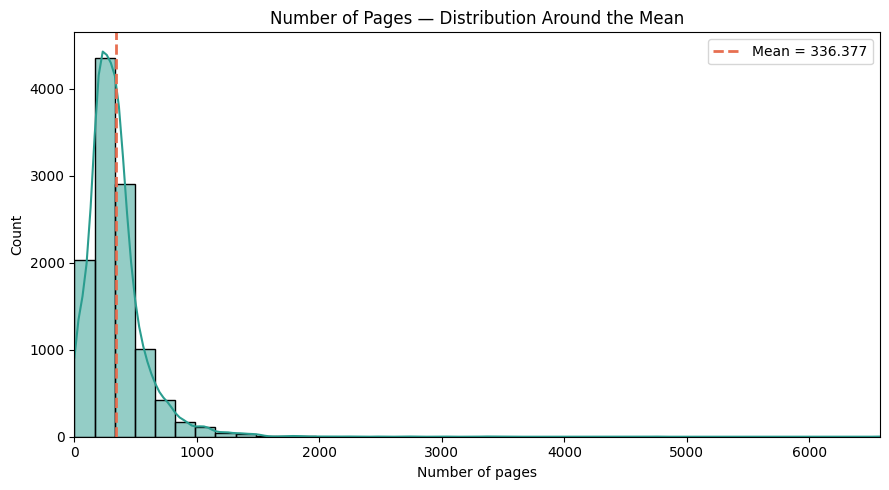

,metric,value
0,mean,336.376921
1,standard_deviation,241.127305
2,minimum,0.000000
3,maximum,6576.000000
4,count,11127.000000


(<Figure size 900x500 with 1 Axes>,
 <Axes: title={'center': 'Number of Pages — Distribution Around the Mean'}, xlabel='Number of pages', ylabel='Count'>)

In [294]:
# num_pages
plot_distribution_with_mean(
    df,
    column="num_pages",
    lower=0,
    upper=df["num_pages"].max(),
    title="Number of Pages — Distribution Around the Mean",
    xlabel="Number of pages",
)

## Analysis : Language Codes
------------

In [295]:
language_value_counts = df["language_code"].value_counts(dropna=False)
language_value_counts

language_code
eng      8911
en-US    1409
spa       218
en-GB     214
fre       144
ger        99
jpn        46
mul        19
zho        14
grc        11
por        10
en-CA       7
ita         5
enm         3
lat         3
rus         2
swe         2
ara         1
nl          1
srp         1
msa         1
glg         1
wel         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64

In [296]:
lang_values = language_value_counts.index.to_list()
lang_values

['eng',
 'en-US',
 'spa',
 'en-GB',
 'fre',
 'ger',
 'jpn',
 'mul',
 'zho',
 'grc',
 'por',
 'en-CA',
 'ita',
 'enm',
 'lat',
 'rus',
 'swe',
 'ara',
 'nl',
 'srp',
 'msa',
 'glg',
 'wel',
 'nor',
 'tur',
 'gla',
 'ale']

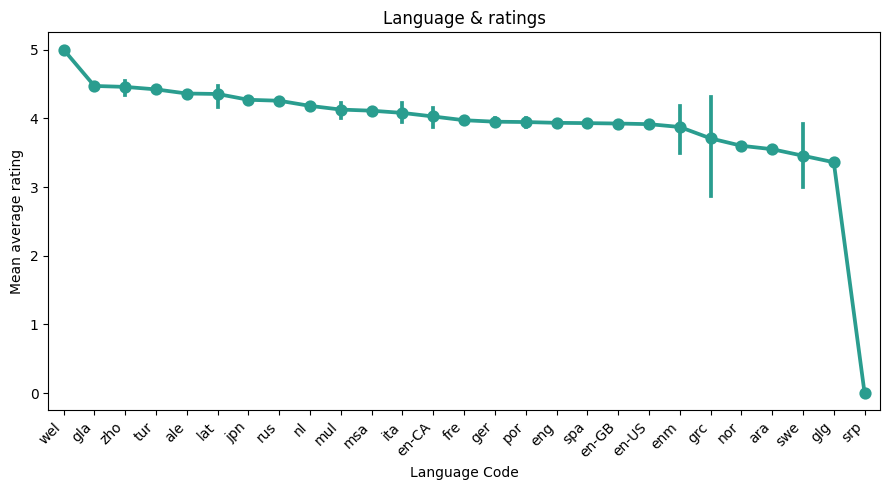

In [297]:
fig, ax = plt.subplots(figsize=(9, 5))

language_value_counts = df["language_code"].value_counts(dropna=False)

language_plot = df[["language_code", "average_rating"]].copy()

order = (
    language_plot.groupby("language_code", dropna=False)["average_rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.pointplot(
    data=language_plot,
    x="language_code",
    y="average_rating",
    order=order,
    errorbar=("ci", 95),
    color="#2a9d8f",
    ax=ax,
)
ax.set_title("Language & ratings")
ax.set_xlabel("Language Code")
ax.set_ylabel("Mean average rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [298]:
# check for multi-language books
multi_lang = (
    df.groupby(["title", "authors"])["language_code"]
    .agg(n_languages="nunique", languages=lambda s: sorted(s.dropna().unique()))
    .reset_index()
    .query("n_languages > 1")
    .sort_values("n_languages", ascending=False)
    .head(50)
)
multi_lang

,title,authors,n_languages,languages
341,A Tale of Two Cities,Charles Dickens/Gillen D'Arcy Wood,3,"[en-GB, en-US, eng]"
6058,Sahara (Dirk Pitt #11),Clive Cussler,3,"[en-US, eng, spa]"
4,'Salem's Lot,Stephen King,2,"[en-US, eng]"
421,Act of Treason (Mitch Rapp #9),Vince Flynn,2,"[en-US, eng]"
6,'Salem's Lot,Stephen King/Ron McLarty,2,"[en-US, eng]"
645,Angels & Demons (Robert Langdon #1),Dan Brown,2,"[en-US, eng]"
672,Anna Karenina,Leo Tolstoy/Richard Pevear/Larissa Volokhonsky,2,"[en-US, eng]"
724,Are We There Yet?,David Levithan,2,"[en-US, eng]"
794,At Risk (Winston Garano #1),Patricia Cornwell,2,"[en-US, eng]"
805,Atlas Shrugged,Ayn Rand,2,"[en-US, eng]"
